# **Sales Analysis**

### **Brief Project Description**
This project analyzes retail sales data from 2012 to 2015 to evaluate business performance, identify growth drivers, and eliminate profit leakages. By examining these multi-year transaction records, the analysis aims to answer four critical questions: determining which product categories generate the highest profit margins, uncovering temporal sales trends over time, mapping revenue and profit distribution across global regions, and evaluating how promotional discounting impacts net profitability.

Ultimately, the project aims to deliver actionable business insights that optimize pricing strategies, improve regional resource allocation, and maximize overall profitability without sacrificing top-line sales growth.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Setup matplotlib to display plots inline
%matplotlib inline

###**Project Dataset**
The dataset used in this project will be a fact table called **'Retail Sales Analysis Data'** which is a CSV file.

In [3]:
df = pd.read_csv('Retail Sales Analysis Data.csv')

### **Exploratory Analysis**
Let's inspect the dataframe to look at the properties of the data and have a feel of the dataframe.

We will start by looking at the number of rows and columns the dataset contains with the .shape function, to get an idea of the size.

We will then look at the first 5 rows with the .head() function, to get a "sneak peek" of the dataset.

Then next, we will study the properties of the fields with the .info() and .describe() functions.



In [4]:
df.shape

(1000, 24)

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   object 
 2   Order Date      1000 non-null   object 
 3   Ship Date       1000 non-null   object 
 4   Ship Mode       1000 non-null   object 
 5   Customer ID     1000 non-null   object 
 6   Customer Name   1000 non-null   object 
 7   Segment         1000 non-null   object 
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   object 
 10  State           1000 non-null   object 
 11  Country         1000 non-null   object 
 12  Region          1000 non-null   object 
 13  Market          1000 non-null   object 
 14  Product ID      1000 non-null   object 
 15  Category        1000 non-null   object 
 16  Sub-Category    1000 non-null   object 
 17  Product Name    1000 non-null   ob

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,1000.000000,194.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,25079.328000,53966.170103,1710.971470,5.55800,0.092840,288.920440,272.384897
std,12897.726632,33734.306466,1259.239238,2.71846,0.148666,574.504782,176.160716
min,58.000000,2920.000000,1.910000,1.00000,0.000000,-3059.820000,1.070000
25%,15118.750000,19134.000000,826.907500,4.00000,0.000000,10.037500,209.827500
50%,25084.500000,60564.000000,1585.115000,5.00000,0.000000,190.685000,258.897500
75%,34524.000000,88187.500000,2477.812500,7.00000,0.150000,518.872500,351.070250
max,51284.000000,98198.000000,9892.740000,14.00000,0.800000,4946.370000,923.630000


### **Data Cleaning**
The dataset is pretty much in good shape, and there are no null values in the fields we need for the analysis.

However, we do need to change the 'Order Date' and 'Ship Date' fields to Date/Time format with the appropriate function.

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


### **Basic Analysis**
We are going to analyse the data to get the following:

1.   Total Sales
2.   Total Profit


1.   Top 10 Products by Sales
2.   Top 10 Regions by Sales

1.   The Relationship between Sales and Profit
2.   The Relationship between Discount and Profit












In [9]:
# The Total Sales
total_sales = df['Sales'].sum()
print(f"{total_sales}")

1710971.47


In [10]:
# The Total Profit
total_profit = df['Profit'].sum()
print(f"{total_profit}")

288920.44000000006


In [11]:
# Identify the top 10 selling products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

,Sales
Product Name,
"Motorola Smart Phone, Full Size",48542.52
"Apple Smart Phone, Full Size",42303.44
"Cisco Smart Phone, Full Size",41325.20
"Nokia Smart Phone, Full Size",27661.97
"Samsung Smart Phone, Cordless",25438.59
"Hoover Stove, Red",23477.81
"Motorola Smart Phone, with Caller ID",23239.44
"Harbour Creations Executive Leather Armchair, Adjustable",22145.80
"Cisco Smart Phone, with Caller ID",22047.89


In [12]:
# Analyse sales by region and find the top 10 regions.
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).head(10)
sales_by_region

,Sales
Region,
Western Europe,259576.28
Oceania,220809.08
Southern Asia,205466.26
Eastern Asia,193590.60
Southeastern Asia,147337.60
Central America,140966.21
Northern Europe,103888.63
Southern Europe,94441.11
South America,64550.54


In [13]:
# Examine the relationship between sales and profit.
sales_profit_corr = df['Sales'].corr(df['Profit'])
print(f"{sales_profit_corr}")

0.5336756228051002


In [14]:
# Examine the relationship between discount and profit
discount_profit_corr = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {discount_profit_corr:.2f}\n")

Correlation between Discount and Profit: -0.51



### **Visualizations**


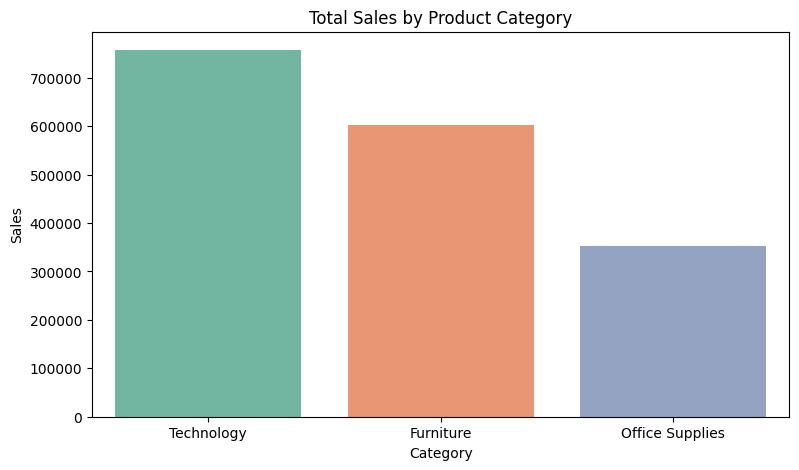

In [17]:
# Create a bar chart of sales by product category with distinct bar colors
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x='Category',
    y='Sales',
    hue='Category',
    palette='Set2',
    legend=False,
    estimator=sum,
    errorbar=None
)
plt.title('Total Sales by Product Category')
plt.show()

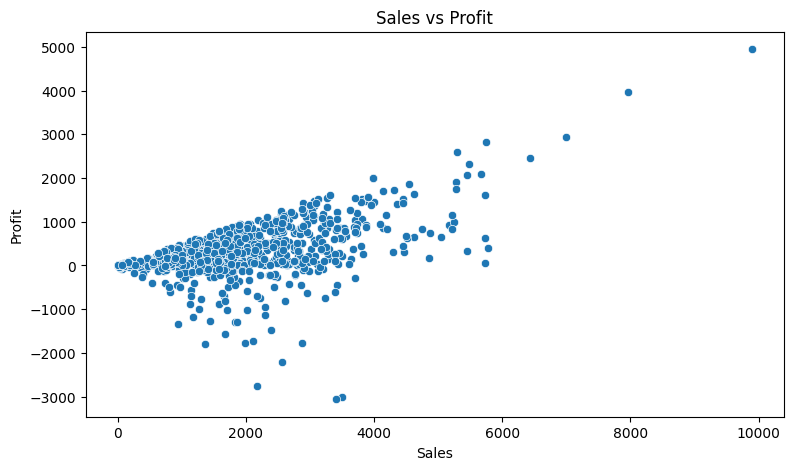

In [18]:
# Generate a scatter plot of sales vs profit.
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Sales', y='Profit')
plt.title('Sales vs Profit')
plt.show()

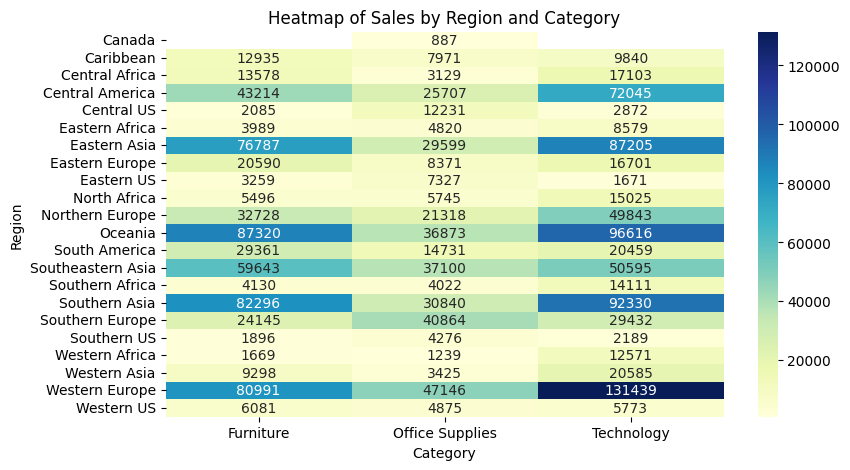

In [19]:
# Produce a heatmap of sales by region and product category.
heatmap_data = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap of Sales by Region and Category')
plt.show()

# **Conclusion**

The analysis has revealed a strong business generating 1,710,971.47 in total sales and 288,920.44 in profit, anchored by Technology (756,983.02 sales; 145,068.68 profit). In terms of regional sales performance, Western Europe (259,576.28) and Oceania (220,809.08) lead in total sales revenue, and  Western Europe (48,124.20) and Central Europe (35,160.85) generate the highest overall profit figures.

While monthly sales trend upward over time with seasonal surges and correlate positively with profit (with r being approximately 0.53), our discount vs profit analysis proves a clear negative correlation (r = -0.51), which clearly shows that aggressive discounts reduce profits, which is quite logical.

To optimize business performance, management must dial down discounts, re-evaluate sales strategies on low-selling products like office supplies, and leverage the already strong market performance in the more profitable regions like Western Europe and Oceania. Next, we should look closely at customer segments to spot and fix unprofitable orders.